In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\swain\Downloads\Adult Dataset\adult.csv", header = None, names = ['age','workclass','fnlwgt','education','education_num','marital_status','occupation','relationship','race','sex','capital_gain','capital_loss','hours_per_week','native_country','earning_potential'])


In [3]:
df.shape

(32561, 15)

In [4]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,earning_potential
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
for col in df.columns:
    print(f"\n-----{col}-----")
    print(df[col].value_counts())


-----age-----
age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64

-----workclass-----
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

-----fnlwgt-----
fnlwgt
164190    13
203488    13
123011    13
148995    12
121124    12
          ..
232784     1
325573     1
140176     1
318264     1
257302     1
Name: count, Length: 21648, dtype: int64

-----education-----
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th         

In [6]:
(df == ' ?').sum()

age                     0
workclass            1836
fnlwgt                  0
education               0
education_num           0
marital_status          0
occupation           1843
relationship            0
race                    0
sex                     0
capital_gain            0
capital_loss            0
hours_per_week          0
native_country        583
earning_potential       0
dtype: int64

In [7]:
df = df.replace(' ?',np.nan)

In [8]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
df.isna().sum()

age                  0
workclass            0
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation           0
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country       0
earning_potential    0
dtype: int64

In [10]:
df = df[~df['workclass'].isin([' Without-pay',' Never-worked'])]
df['workclass'].value_counts()

workclass
Private             24532
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Name: count, dtype: int64

In [11]:
num_df = df.select_dtypes(include='number')
neg_mask= num_df < 0
print("count negative per column:\n",neg_mask.sum())

count negative per column:
 age               0
fnlwgt            0
education_num     0
capital_gain      0
capital_loss      0
hours_per_week    0
dtype: int64


In [12]:
df = df.drop(['capital_gain','capital_loss'],axis=1)
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'hours_per_week', 'native_country', 'earning_potential'],
      dtype='object')

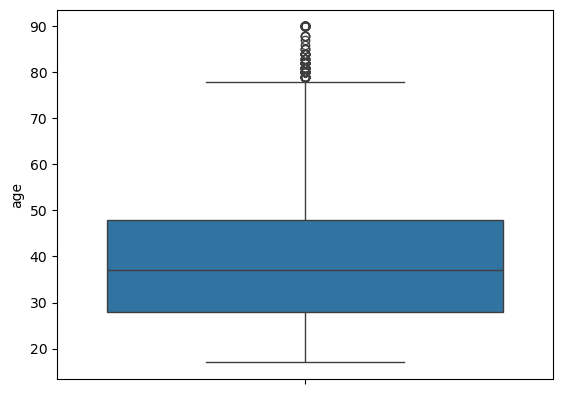

In [13]:
sns.boxplot(y=df['age'])
plt.show()

In [14]:
five_number_summary = df.age.describe()
five_number_summary

count    32540.000000
mean        38.581561
std         13.634290
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

In [15]:
IQR = five_number_summary['75%']-five_number_summary['25%']
upper_limit = (1.5*IQR)+five_number_summary['75%']
lower_limit = five_number_summary['25%']-(1.5*IQR)
print(IQR)
print(upper_limit)
print(lower_limit)

20.0
78.0
-2.0


In [16]:
df = df[(df['age']>=-2.0)&(df['age']<=78)]

In [17]:
df.shape

(32397, 13)

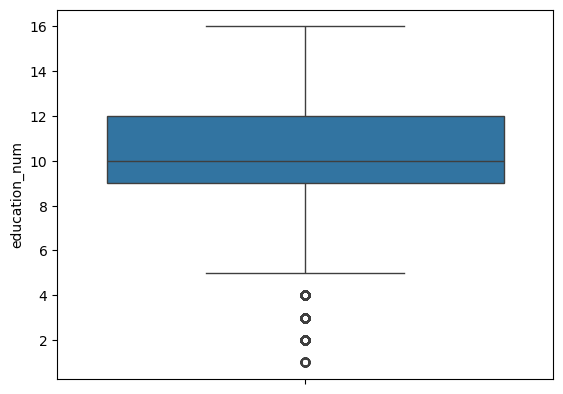

In [18]:
sns.boxplot(y=df['education_num'])
plt.show()

In [19]:
five_number_summary = df.education_num.describe()
five_number_summary

count    32397.000000
mean        10.084174
std          2.567904
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education_num, dtype: float64

In [20]:
IQR = five_number_summary['75%']-five_number_summary['25%']
upper_limit = (1.5*IQR)+five_number_summary['75%']
lower_limit = five_number_summary['25%']-(1.5*IQR)
print(IQR)
print(upper_limit)
print(lower_limit)

3.0
16.5
4.5


In [21]:
df = df[(df['age']>=3.0)]

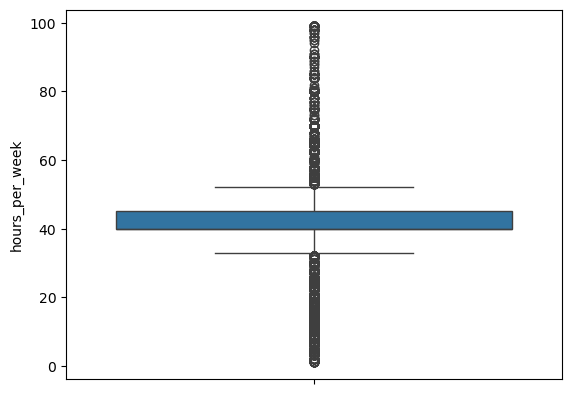

In [22]:
sns.boxplot(y=df['hours_per_week'])
plt.show()

In [23]:
five_number_summary = df.hours_per_week.describe()
five_number_summary

count    32397.000000
mean        40.497299
std         12.291666
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours_per_week, dtype: float64

In [24]:
IQR = five_number_summary['75%']-five_number_summary['25%']
upper_limit = (1.5*IQR)+five_number_summary['75%']
lower_limit = five_number_summary['25%']-(1.5*IQR)
print(IQR)
print(upper_limit)
print(lower_limit)

5.0
52.5
32.5


In [25]:
df = df[(df['hours_per_week']>=30.0)&(df['hours_per_week']<=70)]

In [26]:
df.shape

(27887, 13)

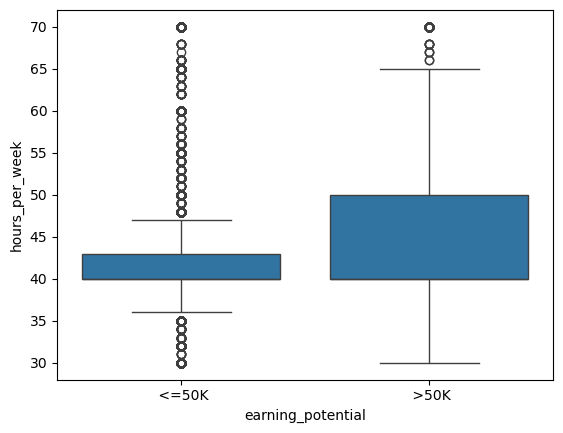

In [27]:
sns.boxplot(x=df['earning_potential'], y=df['hours_per_week'])
plt.show()

In [28]:
df['experience'] = df['age'] - df['education_num']-5

In [29]:
df1 = df.copy()
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in df.select_dtypes(include = 'object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

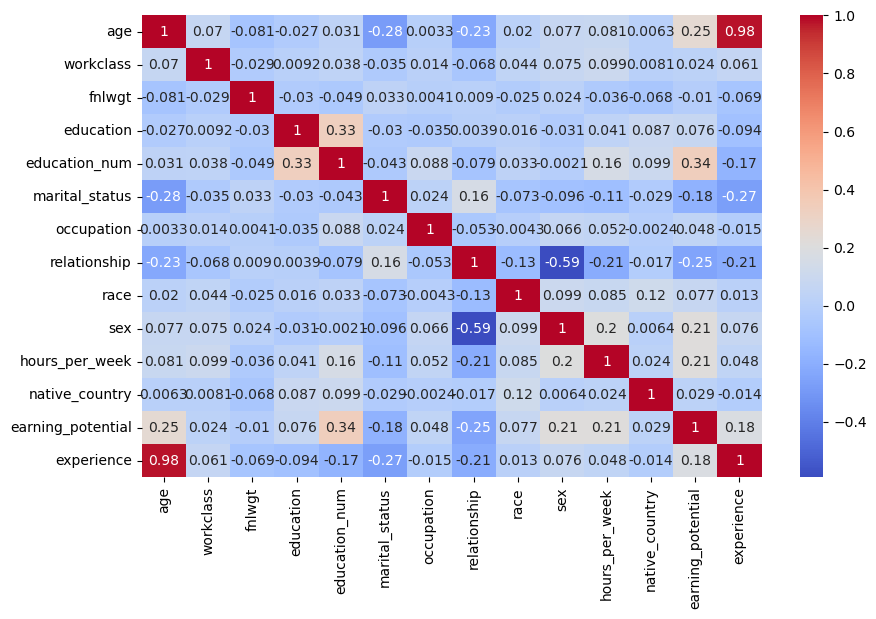

In [30]:
corr = df.corr(numeric_only = True)
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [31]:
X = df.drop(['earning_potential'],axis=1)
Y = df['earning_potential']

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = RandomForestClassifier()
model.fit(X_train, Y_train)

# Predictions
Y_pred = model.predict(X_test)


In [34]:
# Evaluation
accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8065614915740409
Precision: 0.6540247678018576
Recall: 0.5721056194989844
F1 Score: 0.6103286384976526


In [35]:
sns.barplot(x='occupation',y='earning_potential', data=df, data=df,errorbar = None)
plt.show()

SyntaxError: keyword argument repeated: data (2237392528.py, line 1)

In [ ]:
sns.barplot(x='education_num',y='earning_potential', data=df, data=df,errorbar = None)
plt.show()

In [ ]:
sns.lineplot(x='age',y='earning_potential', data=df,errorbar = None)
plt.show()

In [ ]:
sns.boxplot(x='earning_potential',y='hours_per_week', data=df)
plt.show()